In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [5]:

def preprocess(sample, img_size):
    """Preprocessa le immagini: ridimensionamento e normalizzazione."""
    image = tf.image.resize(sample['image'], img_size) / 255.0  # Normalizza in [0,1]
    label = sample['label']  # Estrai l'etichetta
    return image, label

def load_dataset(split, img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    """

    print(split)
    dataset = tfds.load('oxford_iiit_pet', split=split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset



In [6]:
# Parametri
img_size = (112, 112)
batch_size = 64
noise_factor = 0.4
epochs = 50

# Caricamento dataset
train_ds = load_dataset( split='train[:80%]', img_size=img_size, batch_size=batch_size)
valid_ds = load_dataset( split='train[80%:]', img_size=img_size, batch_size=batch_size)
test_ds  = load_dataset( split='test',        img_size=img_size, batch_size=batch_size)

train[:80%]
train[80%:]
test


In [19]:
def add_noise(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=1.0)
    x_noisy = x + noise_factor * noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 0.1)
    return x_noisy

In [29]:
train_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))
valid_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))

test_ds_noisy = test_ds.map(lambda x, label: (add_noise(x, noise_factor), x))

In [24]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

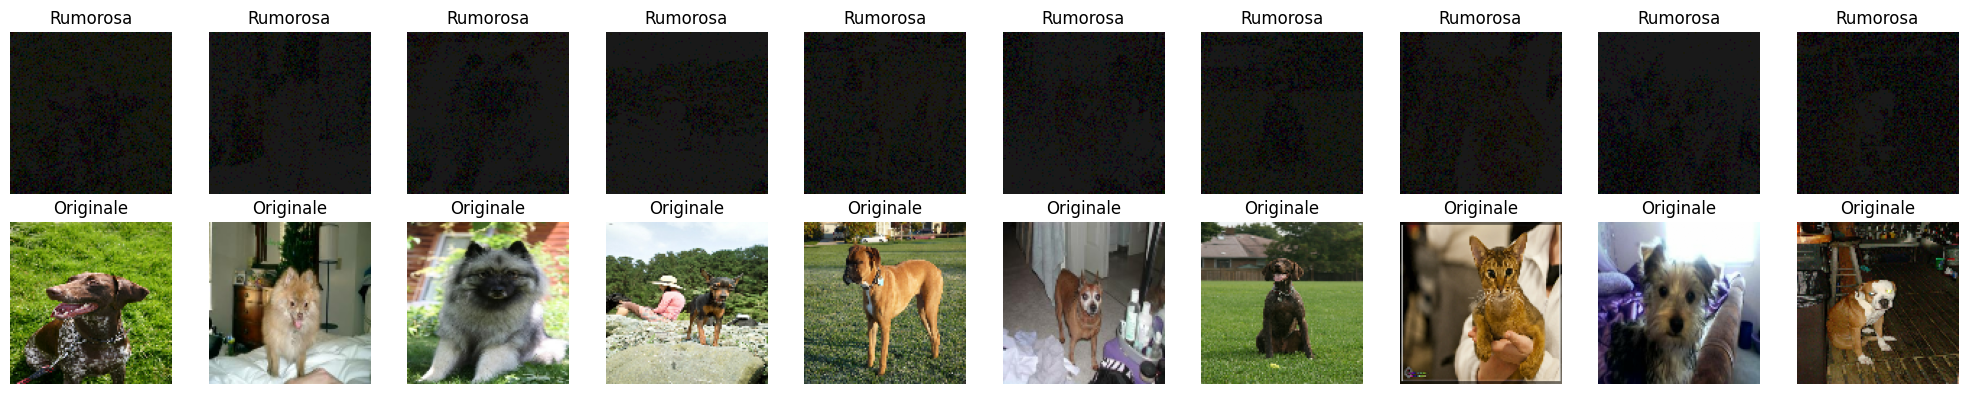

In [25]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


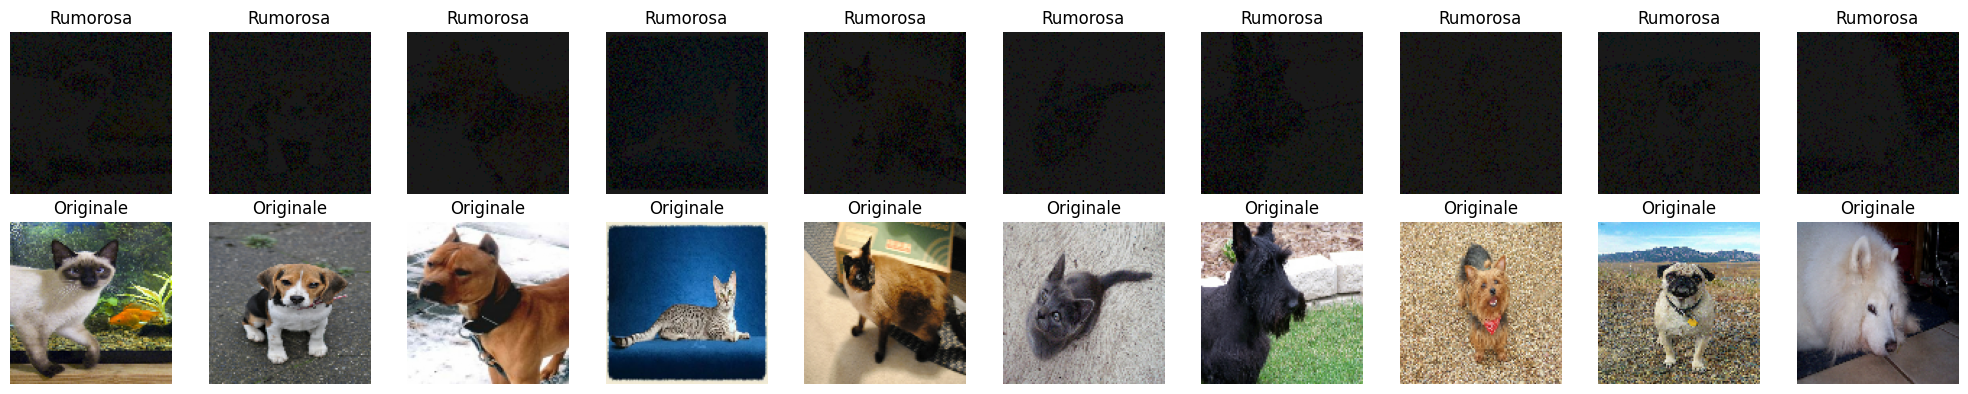

In [26]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

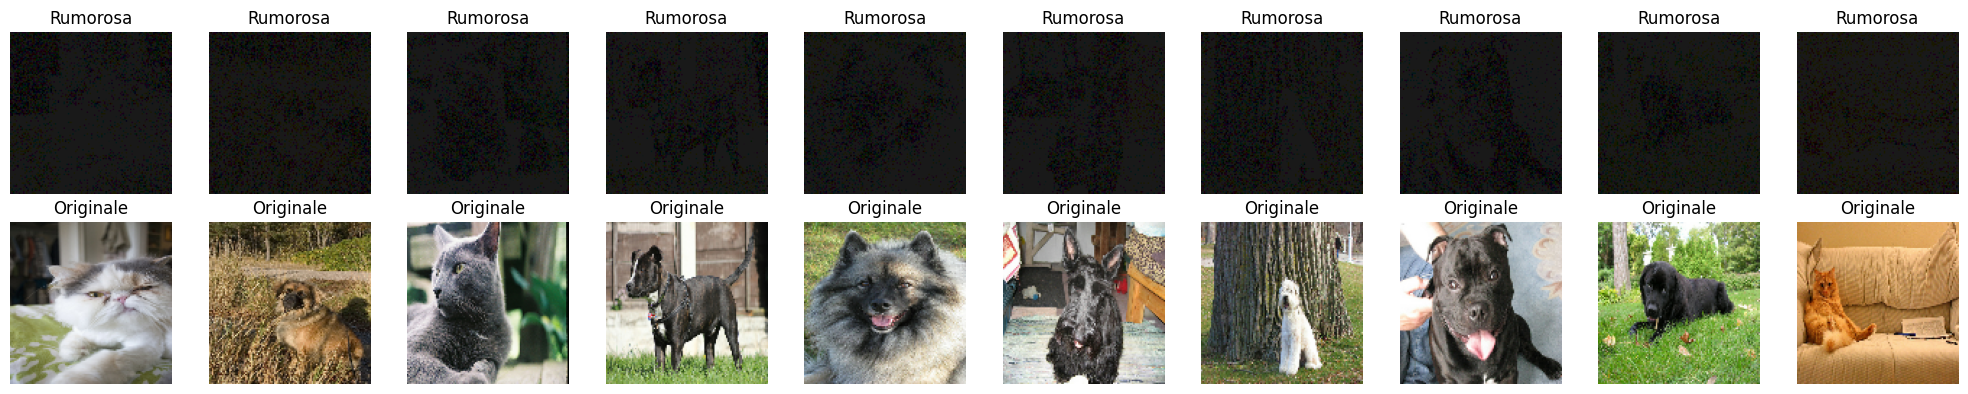

In [30]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(test_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

Creazione modello

In [14]:
def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [15]:
def psnr(original, denoised):
  mse = np.mean((original - denoised) ** 2)
  if mse == 0:
    return float('inf') # immagini identiche
  max_pixel = 1.0 # valore massimo per immagini normalizzate in [0, 1]
  return 10 * np.log10((max_pixel ** 2) / mse)

In [16]:
def build_autoencoder(input_shape):
    """
    Costruisce un autoencoder convoluzionale per immagini a colori.
    Parametri:
      input_shape: forma dell'immagine in input (es. (32,32,3))
    Ritorna:
      autoencoder: modello compilato
    """
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return autoencoder

def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, epochs=50, batch_size=128):
    """
    Addestra l'autoencoder utilizzando le immagini rumorose come input e quelle originali come target.
    """
    history = autoencoder.fit(x_train_noisy, x_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(x_test_noisy, x_test))
    return history

In [17]:
autoencoder = build_autoencoder(input_shape=(img_size[0], img_size[1], 3))
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,307 (446.51 KB)

 Trainable params: 114,307 (446.51 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = autoencoder.fit(train_ds_noisy,
                validation_data=valid_ds_noisy,
                batch_size=batch_size,
                epochs=50)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 338ms/step - accuracy: 0.5881 - loss: 0.6463 - val_accuracy: 0.5731 - val_loss: 0.5754
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 334ms/step - accuracy: 0.5583 - loss: 0.5706 - val_accuracy: 0.5817 - val_loss: 0.5600
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 321ms/step - accuracy: 0.5768 - loss: 0.5605 - val_accuracy: 0.5817 - val_loss: 0.5567
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 318ms/step - accuracy: 0.5639 - loss: 0.5571 - val_accuracy: 0.5800 - val_loss: 0.5533
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 319ms/step - accuracy: 0.5820 - loss: 0.5521 - val_accuracy: 0.6176 - val_loss: 0.5511
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 356ms/step - accuracy: 0.6099 - loss: 0.5516 - val_accuracy: 0.6027 - val_loss: 0.5509
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 334ms/step - accuracy: 0.6045 - loss: 0.5537 - val_accuracy: 0.6167 - val_loss: 0.5501
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 320ms/step - accuracy: 0.6135 - loss: 0.5518 - val_accu

Predict e grafici

In [32]:
decoded_imgs = autoencoder.predict(test_ds_noisy)

58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step


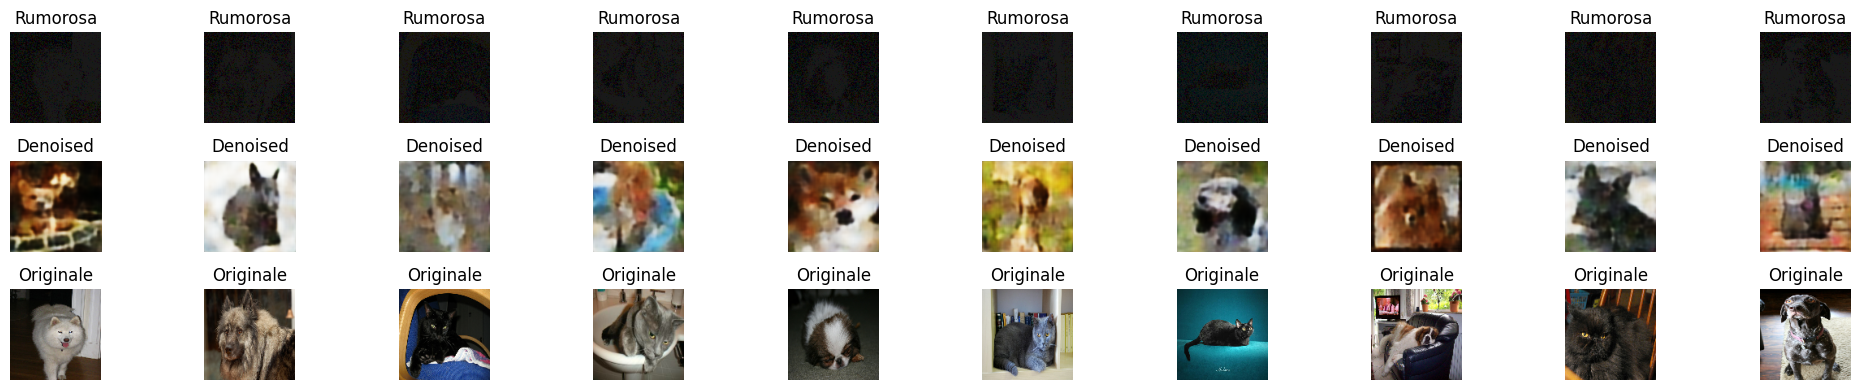

In [34]:
batch = next(iter(test_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()
plot_denoising_results(x_noisy_np, decoded_imgs, x_original_np, n=10)

In [35]:
print(history.history.keys())  # mostra le chiavi disponibili

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [36]:
print(history.history['accuracy'])

[0.5842110514640808, 0.563948392868042, 0.575088620185852, 0.5714444518089294, 0.5891115665435791, 0.6071439981460571, 0.6071137189865112, 0.6102569103240967, 0.612958550453186, 0.6114788055419922, 0.6128462553024292, 0.6135605573654175, 0.6147528290748596, 0.619999885559082, 0.6232470870018005, 0.6291866302490234, 0.633857011795044, 0.6510925889015198, 0.665501058101654, 0.6665708422660828, 0.6668264865875244, 0.665120005607605, 0.6696152687072754, 0.6661880612373352, 0.665165364742279, 0.6675223708152771, 0.6709907650947571, 0.6755350232124329, 0.6748579740524292, 0.6739561557769775, 0.6760616302490234, 0.6790679693222046, 0.6790801882743835, 0.6770516037940979, 0.6776544451713562, 0.678592324256897, 0.6803721189498901, 0.6823478937149048, 0.6808099746704102, 0.681533932685852, 0.6789758205413818, 0.6820165514945984, 0.6809890866279602, 0.68378084897995, 0.6806026101112366, 0.6817249059677124, 0.6835870146751404, 0.6847822070121765, 0.6859477758407593, 0.6832185387611389]


In [37]:
autoencoder.save('new_autoencoder.keras')

In [38]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

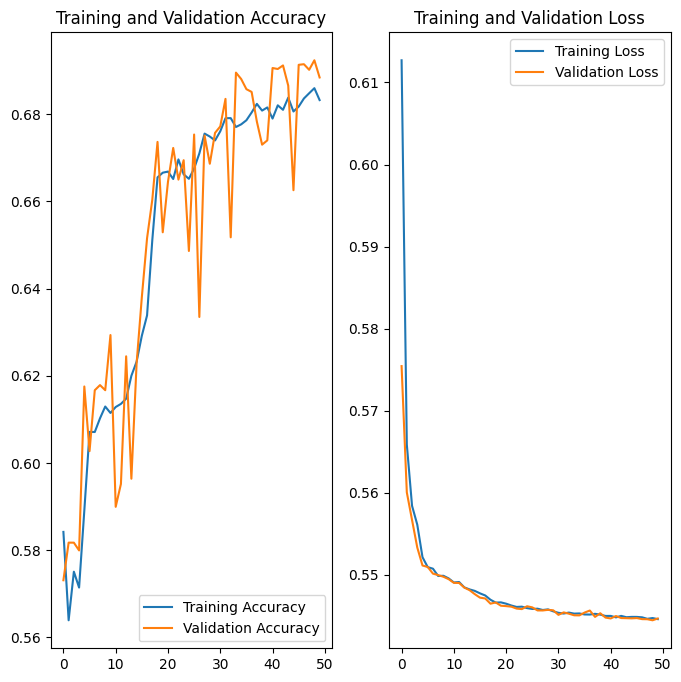

In [39]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [40]:
from skimage.metrics import peak_signal_noise_ratio as psnr

In [41]:
psnr_values = [psnr(x_noisy_np[i], decoded_imgs[i], data_range=1.0) for i in range(len(test_ds_noisy))]


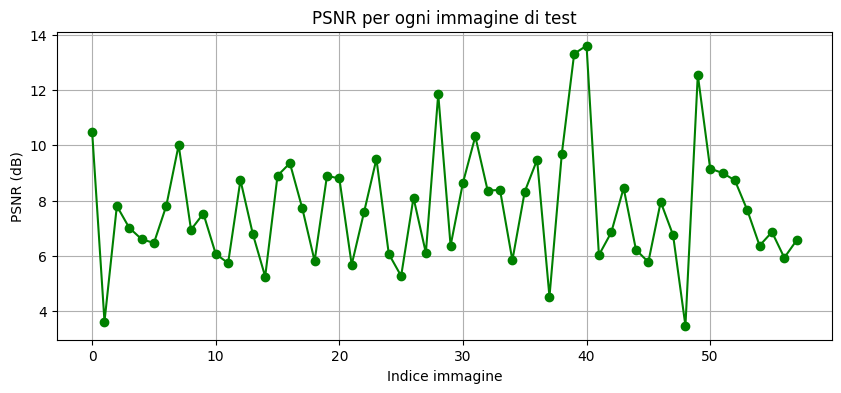

Media PSNR sul test set: 7.72 dB


In [42]:

# Plot dei PSNR per ogni immagine
plt.figure(figsize=(10, 4))
plt.plot(psnr_values, marker='o', linestyle='-', color='green')
plt.title('PSNR per ogni immagine di test')
plt.xlabel('Indice immagine')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()

# (Facoltativo) Media PSNR
print(f"Media PSNR sul test set: {np.mean(psnr_values):.2f} dB")